<a href="https://colab.research.google.com/github/galaxys32013aa-commits/zomato-delivery-analysis/blob/main/zomato_delivery_app.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Загружаем данные

https://www.kaggle.com/datasets/rishikeshkonapure/zomato/data

https://drive.google.com/file/d/1HiBgxY0u41rGaVhI-X4fpWHrdIbcimMl/view?usp=sharing

In [11]:
! gdown 1HiBgxY0u41rGaVhI-X4fpWHrdIbcimMl

Downloading...
From (original): https://drive.google.com/uc?id=1HiBgxY0u41rGaVhI-X4fpWHrdIbcimMl
From (redirected): https://drive.google.com/uc?id=1HiBgxY0u41rGaVhI-X4fpWHrdIbcimMl&confirm=t&uuid=f6f404c3-fd1b-4a59-aacb-ca1f62bf5403
To: /content/zomato-delivery-app.zip
100% 93.3M/93.3M [00:02<00:00, 32.8MB/s]


In [12]:
! unzip /content/zomato-delivery-app.zipgq7fvfee.part

unzip:  cannot find or open /content/zomato-delivery-app.zipgq7fvfee.part, /content/zomato-delivery-app.zipgq7fvfee.part.zip or /content/zomato-delivery-app.zipgq7fvfee.part.ZIP.


# Импортируем необходимые библиотеки и прочитаем данные

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import KNNImputer

plt.style.use("dark_background")

In [14]:
df_raw = pd.read_csv('/content/zomato-delivery-app.zip')

In [15]:
df_raw

,url,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),reviews_list,menu_item,listed_in(type),listed_in(city)
0,https://www.zomato.com/bangalore/jalsa-banasha...,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,Yes,Yes,4.1/5,775,080 42297555\r\n+91 9743772233,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800,"[('Rated 4.0', 'RATED\n A beautiful place to ...",[],Buffet,Banashankari
1,https://www.zomato.com/bangalore/spice-elephan...,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,Yes,No,4.1/5,787,080 41714161,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800,"[('Rated 4.0', 'RATED\n Had been here for din...",[],Buffet,Banashankari
2,https://www.zomato.com/SanchurroBangalore?cont...,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,Yes,No,3.8/5,918,+91 9663487993,Banashankari,"Cafe, Casual Dining","Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",800,"[('Rated 3.0', ""RATED\n Ambience is not that ...",[],Buffet,Banashankari
3,https://www.zomato.com/bangalore/addhuri-udupi...,"1st Floor, Annakuteera, 3rd Stage, Banashankar...",Addhuri Udupi Bhojana,No,No,3.7/5,88,+91 9620009302,Banashankari,Quick Bites,Masala Dosa,"South Indian, North Indian",300,"[('Rated 4.0', ""RATED\n Great food and proper...",[],Buffet,Banashankari
4,https://www.zomato.com/bangalore/grand-village...,"10, 3rd Floor, Lakshmi Associates, Gandhi Baza...",Grand Village,No,No,3.8/5,166,+91 8026612447\r\n+91 9901210005,Basavanagudi,Casual Dining,"Panipuri, Gol Gappe","North Indian, Rajasthani",600,"[('Rated 4.0', 'RATED\n Very good restaurant ...",[],Buffet,Banashankari
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51712,https://www.zomato.com/bangalore/best-brews-fo...,"Four Points by Sheraton Bengaluru, 43/3, White...",Best Brews - Four Points by Sheraton Bengaluru...,No,No,3.6 /5,27,080 40301477,Whitefield,Bar,NaN,Continental,"1,500","[('Rated 5.0', ""RATED\n Food and service are ...",[],Pubs and bars,Whitefield
51713,https://www.zomato.com/bangalore/vinod-bar-and...,"Number 10, Garudachar Palya, Mahadevapura, Whi...",Vinod Bar And Restaurant,No,No,NaN,0,+91 8197675843,Whitefield,Bar,NaN,Finger Food,600,[],[],Pubs and bars,Whitefield
51714,https://www.zomato.com/bangalore/plunge-sherat...,Sheraton Grand Bengaluru Whitefield Hotel & Co...,Plunge - Sheraton Grand Bengaluru Whitefield H...,No,No,NaN,0,NaN,Whitefield,Bar,NaN,Finger Food,"2,000",[],[],Pubs and bars,Whitefield
51715,https://www.zomato.com/bangalore/chime-sherato...,Sheraton Grand Bengaluru Whitefield Hotel & Co...,Chime - Sheraton Grand Bengaluru Whitefield Ho...,No,Yes,4.3 /5,236,080 49652769,"ITPL Main Road, Whitefield",Bar,"Cocktails, Pizza, Buttermilk",Finger Food,"2,500","[('Rated 4.0', 'RATED\n Nice and friendly pla...",[],Pubs and bars,Whitefield


# Проведем краткий обзор данных

In [16]:
df_raw.head(10)

,url,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),reviews_list,menu_item,listed_in(type),listed_in(city)
0,https://www.zomato.com/bangalore/jalsa-banasha...,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,Yes,Yes,4.1/5,775,080 42297555\r\n+91 9743772233,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800,"[('Rated 4.0', 'RATED\n A beautiful place to ...",[],Buffet,Banashankari
1,https://www.zomato.com/bangalore/spice-elephan...,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,Yes,No,4.1/5,787,080 41714161,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800,"[('Rated 4.0', 'RATED\n Had been here for din...",[],Buffet,Banashankari
2,https://www.zomato.com/SanchurroBangalore?cont...,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,Yes,No,3.8/5,918,+91 9663487993,Banashankari,"Cafe, Casual Dining","Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",800,"[('Rated 3.0', ""RATED\n Ambience is not that ...",[],Buffet,Banashankari
3,https://www.zomato.com/bangalore/addhuri-udupi...,"1st Floor, Annakuteera, 3rd Stage, Banashankar...",Addhuri Udupi Bhojana,No,No,3.7/5,88,+91 9620009302,Banashankari,Quick Bites,Masala Dosa,"South Indian, North Indian",300,"[('Rated 4.0', ""RATED\n Great food and proper...",[],Buffet,Banashankari
4,https://www.zomato.com/bangalore/grand-village...,"10, 3rd Floor, Lakshmi Associates, Gandhi Baza...",Grand Village,No,No,3.8/5,166,+91 8026612447\r\n+91 9901210005,Basavanagudi,Casual Dining,"Panipuri, Gol Gappe","North Indian, Rajasthani",600,"[('Rated 4.0', 'RATED\n Very good restaurant ...",[],Buffet,Banashankari
5,https://www.zomato.com/bangalore/timepass-dinn...,"37, 5-1, 4th Floor, Bosco Court, Gandhi Bazaar...",Timepass Dinner,Yes,No,3.8/5,286,+91 9980040002\r\n+91 9980063005,Basavanagudi,Casual Dining,"Onion Rings, Pasta, Kadhai Paneer, Salads, Sal...",North Indian,600,"[('Rated 3.0', 'RATED\n Food 3/5\nAmbience 3/...",[],Buffet,Banashankari
6,https://www.zomato.com/bangalore/rosewood-inte...,"19/1, New Timberyard Layout, Beside Satellite ...",Rosewood International Hotel - Bar & Restaurant,No,No,3.6/5,8,+91 9731716688\r\n080 26740366,Mysore Road,Casual Dining,NaN,"North Indian, South Indian, Andhra, Chinese",800,"[('Rated 5.0', 'RATED\n Awesome food ??Great ...",[],Buffet,Banashankari
7,https://www.zomato.com/bangalore/onesta-banash...,"2469, 3rd Floor, 24th Cross, Opposite BDA Comp...",Onesta,Yes,Yes,4.6/5,2556,080 48653961\r\n080 48655715,Banashankari,"Casual Dining, Cafe","Farmhouse Pizza, Chocolate Banana, Virgin Moji...","Pizza, Cafe, Italian",600,"[('Rated 5.0', 'RATED\n I personally really l...",[],Cafes,Banashankari
8,https://www.zomato.com/bangalore/penthouse-caf...,"1, 30th Main Road, 3rd Stage, Banashankari, Ba...",Penthouse Cafe,Yes,No,4.0/5,324,+91 8884135549\r\n+91 9449449316,Banashankari,Cafe,"Pizza, Mocktails, Coffee, Nachos, Salad, Pasta...","Cafe, Italian, Continental",700,"[('Rated 3.0', ""RATED\n I had been to this pl...",[],Cafes,Banashankari
9,https://www.zomato.com/bangalore/smacznego-ban...,"2470, 21 Main Road, 25th Cross, Banashankari, ...",Smacznego,Yes,No,4.2/5,504,+91 9945230807\r\n+91 9743804471,Banashankari,Cafe,"Waffles, Pasta, Coleslaw Sandwich, Choco Waffl...","Cafe, Mexican, Italian, Momos, Beverages",550,"[('Rated 4.0', ""RATED\n Easy to locate\nVFM 3...",[],Cafes,Banashankari


Количество строк и столбцов

In [17]:
df_raw.shape

(51717, 17)

In [18]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51717 entries, 0 to 51716
Data columns (total 17 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   url                          51717 non-null  object
 1   address                      51717 non-null  object
 2   name                         51717 non-null  object
 3   online_order                 51717 non-null  object
 4   book_table                   51717 non-null  object
 5   rate                         43942 non-null  object
 6   votes                        51717 non-null  int64 
 7   phone                        50509 non-null  object
 8   location                     51696 non-null  object
 9   rest_type                    51490 non-null  object
 10  dish_liked                   23639 non-null  object
 11  cuisines                     51672 non-null  object
 12  approx_cost(for two people)  51371 non-null  object
 13  reviews_list                 51

# Перейдем к обработке данных (удаление ненужных столбцов, работа с дубликатами, пропусками, преобразование данных и тд)

Для начала сделаем копию датафрейма перед преобразованиями, чтобы всегда иметь возможность обратиться к исходным данным, а работать дальше будем с копией

In [19]:
df=df_raw.copy()

Теперь удалим следующие колонки: url, address, phone, reviews_list, menu_item, dish_liked, listed_in(city), так как они не несут никакой пользы для анализа данных

listed_in(city) удаляем поскольку у нас есть колонка location с аналогичной информацией

In [20]:
df = df.drop(columns=['url','address','phone','reviews_list','menu_item','dish_liked','listed_in(city)'], axis = 1)

Изменим названия некоторых столбцов, чтобы они были более понятными

In [21]:
df=df.rename(columns={'name':'restaurant_name','rate':'rating','approx_cost(for two people)':'cost_for_two'})

In [22]:
df.head()

,restaurant_name,online_order,book_table,rating,votes,location,rest_type,cuisines,cost_for_two,listed_in(type)
0,Jalsa,Yes,Yes,4.1/5,775,Banashankari,Casual Dining,"North Indian, Mughlai, Chinese",800,Buffet
1,Spice Elephant,Yes,No,4.1/5,787,Banashankari,Casual Dining,"Chinese, North Indian, Thai",800,Buffet
2,San Churro Cafe,Yes,No,3.8/5,918,Banashankari,"Cafe, Casual Dining","Cafe, Mexican, Italian",800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7/5,88,Banashankari,Quick Bites,"South Indian, North Indian",300,Buffet
4,Grand Village,No,No,3.8/5,166,Basavanagudi,Casual Dining,"North Indian, Rajasthani",600,Buffet


Уберем лишние пробелы в названиях столбцов, если таковые имеются

In [23]:
df.columns= df.columns.str.replace(" ","")

Проверим данные на наличие дубликатов и удалим их

In [24]:
df.duplicated().sum()

np.int64(16706)

In [25]:
df = df.drop_duplicates()

Проверяем результат

In [26]:
df.shape

(35011, 10)

In [27]:
df.duplicated().sum()

np.int64(0)

Заметим в информации о дата фрейме, что такие колонки, как рейтинг и стоимость, должны быть типа float или int

Для начала проведем проверку на уникальные значения

In [28]:
print(f'There are {len(df["rating"].unique())} values are unique in rating column')

df['rating'].unique()

There are 65 values are unique in rating column


array(['4.1/5', '3.8/5', '3.7/5', '3.6/5', '4.6/5', '4.0/5', '4.2/5',
       '3.9/5', '3.1/5', '3.0/5', '3.2/5', '3.3/5', '2.8/5', '4.4/5',
       '4.3/5', 'NEW', '2.9/5', '3.5/5', nan, '2.6/5', '3.8 /5', '3.4/5',
       '4.5/5', '2.5/5', '2.7/5', '4.7/5', '2.4/5', '2.2/5', '2.3/5',
       '3.4 /5', '-', '3.6 /5', '4.8/5', '3.9 /5', '4.2 /5', '4.0 /5',
       '4.1 /5', '3.7 /5', '3.1 /5', '2.9 /5', '3.3 /5', '2.8 /5',
       '3.5 /5', '2.7 /5', '2.5 /5', '3.2 /5', '2.6 /5', '4.5 /5',
       '4.3 /5', '4.4 /5', '4.9/5', '2.1/5', '2.0/5', '1.8/5', '4.6 /5',
       '4.9 /5', '3.0 /5', '4.8 /5', '2.3 /5', '4.7 /5', '2.4 /5',
       '2.1 /5', '2.2 /5', '2.0 /5', '1.8 /5'], dtype=object)

Заметим, что
1. помимо значений типа '4.1/5', у нас есть 'NEW', nan, '-'
2. есть лишние пробелы в значениях '3.8 /5', '2.9 /5'
3. ну и конечно небходимо исправить формат, убрав /5


Создадим функцию

In [29]:
def rating(data):
  if data == 'NEW' or data == '-':
    return np.nan
  else:
    data = str(data).split("/")
    data = data[0]
    return float(data)

Применим функцию

In [30]:
df['rating'] = df['rating'].apply(rating)

Проверяем

In [31]:
df['rating'].unique()

array([4.1, 3.8, 3.7, 3.6, 4.6, 4. , 4.2, 3.9, 3.1, 3. , 3.2, 3.3, 2.8,
       4.4, 4.3, nan, 2.9, 3.5, 2.6, 3.4, 4.5, 2.5, 2.7, 4.7, 2.4, 2.2,
       2.3, 4.8, 4.9, 2.1, 2. , 1.8])

Проведем аналогичные действия со столбцом 'cost_for_two'

Проверим уникальные значения

In [32]:
print(f'There are {len(df["cost_for_two"].unique())} values are unique in rating column')

df['cost_for_two'].unique()

There are 71 values are unique in rating column


array(['800', '300', '600', '700', '550', '500', '450', '650', '400',
       '900', '200', '750', '150', '850', '100', '1,200', '350', '250',
       '950', '1,000', '1,500', '1,300', '199', '80', '1,100', '160',
       '1,600', '230', '130', '50', '190', '1,700', nan, '1,400', '180',
       '1,350', '2,200', '2,000', '1,800', '1,900', '330', '2,500',
       '2,100', '3,000', '2,800', '3,400', '40', '1,250', '3,500',
       '4,000', '2,400', '2,600', '120', '1,450', '469', '70', '3,200',
       '60', '560', '240', '360', '6,000', '1,050', '2,300', '4,100',
       '5,000', '3,700', '1,650', '2,700', '4,500', '140'], dtype=object)

Здесь нам нужно убрать запятые в значениях и изменить тип данных

In [33]:
def remove_comma(data):
  if pd.isna(data):
    return np.nan
  else:
      data = str(data).replace(",", "")
      return float(data)

In [34]:
df['cost_for_two'] = df['cost_for_two'].apply(remove_comma)

In [35]:
df['cost_for_two'].unique()

array([ 800.,  300.,  600.,  700.,  550.,  500.,  450.,  650.,  400.,
        900.,  200.,  750.,  150.,  850.,  100., 1200.,  350.,  250.,
        950., 1000., 1500., 1300.,  199.,   80., 1100.,  160., 1600.,
        230.,  130.,   50.,  190., 1700.,   nan, 1400.,  180., 1350.,
       2200., 2000., 1800., 1900.,  330., 2500., 2100., 3000., 2800.,
       3400.,   40., 1250., 3500., 4000., 2400., 2600.,  120., 1450.,
        469.,   70., 3200.,   60.,  560.,  240.,  360., 6000., 1050.,
       2300., 4100., 5000., 3700., 1650., 2700., 4500.,  140.])

Проверим количество пропусков и их процентное соотношение

In [36]:
pd.concat([df.isna().sum().sort_values(ascending=False),
           df.isna().mean().sort_values(ascending=False)],
           axis = 1, keys = ['Missing Count', 'Missing Percentage (%)'])

,Missing Count,Missing Percentage (%)
rating,5097,0.145583
cost_for_two,221,0.006312
rest_type,156,0.004456
cuisines,33,0.000943
location,14,0.000400
restaurant_name,0,0.000000
online_order,0,0.000000
book_table,0,0.000000
votes,0,0.000000
listed_in(type),0,0.000000


<Axes: >

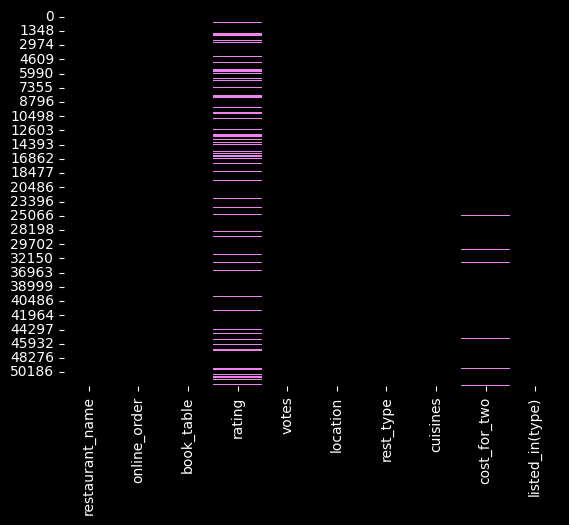

In [37]:
colours = ['black', 'violet']
sns.heatmap(df.isna(), cmap=sns.color_palette(colours), cbar=False)

Заполним пустоты в колонке 'rating' с использованием метода k ближайших соседей (kNN)

In [38]:
df.dtypes

,0
restaurant_name,object
online_order,object
book_table,object
rating,float64
votes,int64
location,object
rest_type,object
cuisines,object
cost_for_two,float64
listed_in(type),object


In [39]:
df.shape

(35011, 10)

Необходимо оставить только числовые значения

In [40]:
df_num = df.select_dtypes('float64')  # оставляем только столбцы с числовыми данными типа float64
df_num.shape

(35011, 2)

In [41]:
imputer = KNNImputer (n_neighbors=5, weights='uniform')  # создаем импьютер
imputer.fit (df_num)  # устанавливаем импьютер на датафрейм
df_num = pd.DataFrame(imputer.transform(df_num), index=df_num.index, columns=df_num.columns)  # заполняем недостающие значения
df_num.head(10)

,rating,cost_for_two
0,4.1,800.0
1,4.1,800.0
2,3.8,800.0
3,3.7,300.0
4,3.8,600.0
5,3.8,600.0
6,3.6,800.0
7,4.6,600.0
8,4.0,700.0
9,4.2,550.0


Записываем обновленные значения в исходный датасет

In [42]:
df['rating'] = df_num['rating']
df['cost_for_two'] = df_num['cost_for_two']

Проверяем

In [43]:
df.isna().sum().sort_values(ascending=False)

,0
rest_type,156
cuisines,33
location,14
restaurant_name,0
online_order,0
book_table,0
votes,0
rating,0
cost_for_two,0
listed_in(type),0


<Axes: >

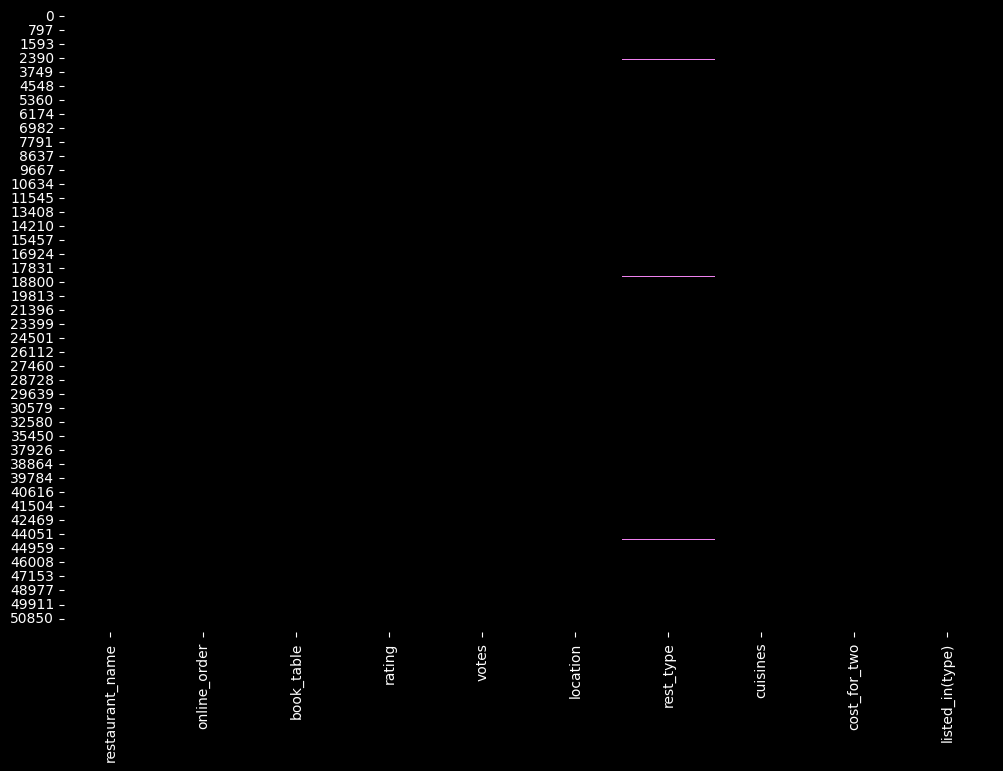

In [44]:
plt.figure(figsize=(12, 8))  # увеличим размер графика, чтобы увидить оставшиеся пропуски
colours = ['black', 'violet']
sns.heatmap(df.isna(), cmap=sns.color_palette(colours), cbar=False)

Поработаем с оставшимися пропусками в 'rest_type', 'cuisines', 'location'

In [45]:
df[['rest_type', 'cuisines', 'location']] = df[['rest_type', 'cuisines', 'location']].fillna('no_data')

In [46]:
df.isna().sum().sort_values(ascending=False)

,0
restaurant_name,0
online_order,0
book_table,0
rating,0
votes,0
location,0
rest_type,0
cuisines,0
cost_for_two,0
listed_in(type),0


Посмотрим на значения в колонке 'rest_type'

In [47]:
print(f'There are {len(df["rest_type"].unique())} values are unique in rating column')

df['rest_type'].unique()

There are 94 values are unique in rating column


array(['Casual Dining', 'Cafe, Casual Dining', 'Quick Bites',
       'Casual Dining, Cafe', 'Cafe', 'Quick Bites, Cafe',
       'Cafe, Quick Bites', 'Delivery', 'Mess', 'Dessert Parlor',
       'Bakery, Dessert Parlor', 'Pub', 'Bakery', 'Takeaway, Delivery',
       'Fine Dining', 'Beverage Shop', 'Sweet Shop', 'Bar',
       'Beverage Shop, Quick Bites', 'Confectionery',
       'Quick Bites, Beverage Shop', 'Dessert Parlor, Sweet Shop',
       'Bakery, Quick Bites', 'Sweet Shop, Quick Bites', 'Kiosk',
       'Food Truck', 'Quick Bites, Dessert Parlor',
       'Beverage Shop, Dessert Parlor', 'Takeaway', 'Pub, Casual Dining',
       'Casual Dining, Bar', 'Dessert Parlor, Beverage Shop',
       'Quick Bites, Bakery', 'Dessert Parlor, Quick Bites',
       'Microbrewery, Casual Dining', 'Lounge', 'Bar, Casual Dining',
       'Food Court', 'Cafe, Bakery', 'no_data', 'Dhaba',
       'Quick Bites, Sweet Shop', 'Microbrewery',
       'Food Court, Quick Bites', 'Pub, Bar', 'Casual Dining, Pub',


In [48]:
df["rest_type"].value_counts()

,count
rest_type,
Quick Bites,12179
Casual Dining,7573
Cafe,2606
Delivery,1520
Dessert Parlor,1504
...,...
"Mess, Quick Bites",1
Pop Up,1
"Bakery, Sweet Shop",1


Можно заметить, что у нас слишком много категорий (94). Анализировать такие данные неудобно, поэтому оставим основные категории, а остальные категории, в которых записей меньше 800, запишем в колонку 'other'

Выявим редкие категории

In [49]:
rest_type = df['rest_type'].value_counts(ascending=False)
rest_less_than_800 = rest_type[rest_type<800]
rest_less_than_800

,count
rest_type,
Bakery,736
Beverage Shop,488
Bar,481
Food Court,427
"Bar, Casual Dining",360
...,...
"Mess, Quick Bites",1
Pop Up,1
"Bakery, Sweet Shop",1


Создадим функцию для замены редких значений на 'other'

In [50]:
def rest_type(data):
    if data in rest_less_than_800:
        return 'Other'
    else:
        return data

Применим изменения

In [51]:
df['rest_type'] = df['rest_type'].apply(rest_type)

In [52]:
df['rest_type'].value_counts()

,count
rest_type,
Quick Bites,12179
Casual Dining,7573
Other,7441
Cafe,2606
Delivery,1520
Dessert Parlor,1504
"Takeaway, Delivery",1227
"Casual Dining, Bar",961


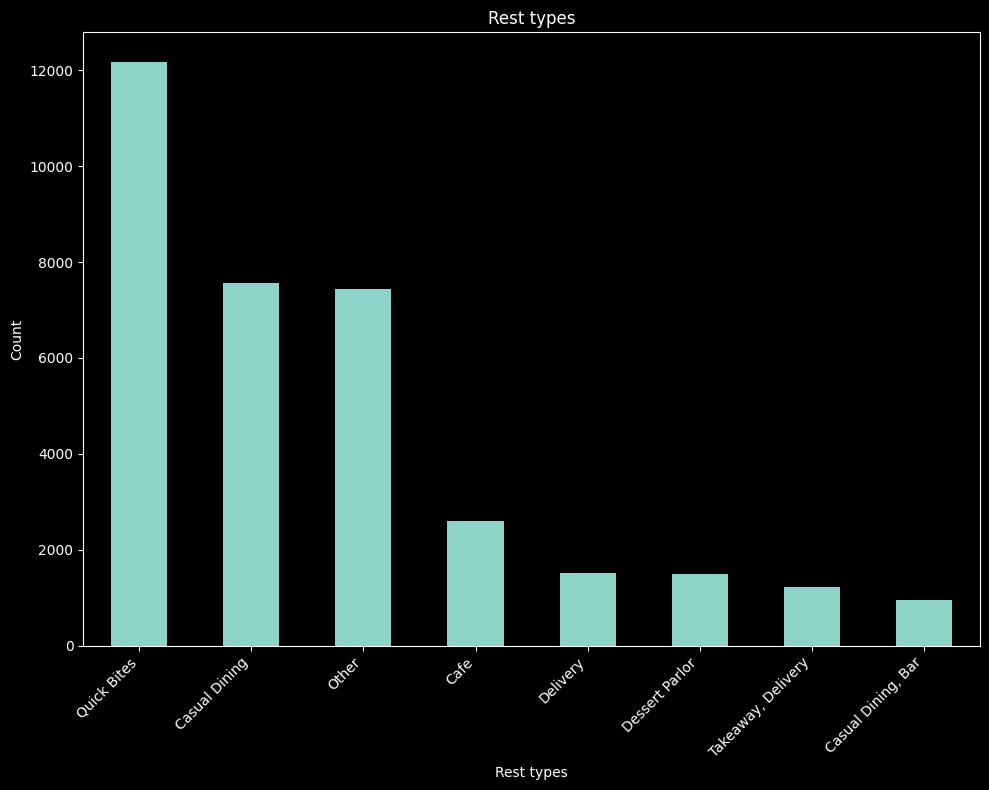

In [53]:
plt.figure(figsize=(10, 8))
df['rest_type'].value_counts(ascending=False).plot(kind='bar')
plt.title('Rest types')
plt.xlabel('Rest types')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [54]:
df.head()

,restaurant_name,online_order,book_table,rating,votes,location,rest_type,cuisines,cost_for_two,listed_in(type)
0,Jalsa,Yes,Yes,4.1,775,Banashankari,Casual Dining,"North Indian, Mughlai, Chinese",800.0,Buffet
1,Spice Elephant,Yes,No,4.1,787,Banashankari,Casual Dining,"Chinese, North Indian, Thai",800.0,Buffet
2,San Churro Cafe,Yes,No,3.8,918,Banashankari,Other,"Cafe, Mexican, Italian",800.0,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7,88,Banashankari,Quick Bites,"South Indian, North Indian",300.0,Buffet
4,Grand Village,No,No,3.8,166,Basavanagudi,Casual Dining,"North Indian, Rajasthani",600.0,Buffet


Cо столбцом 'location' аналогичная ситуация, 94 уникальных значений.

Проделаем все те же действия

In [55]:
print(f'There are {len(df['location'].unique())} values are unique in rating column')

df['location'].unique()

There are 94 values are unique in rating column


array(['Banashankari', 'Basavanagudi', 'Mysore Road', 'Jayanagar',
       'Kumaraswamy Layout', 'Rajarajeshwari Nagar', 'Vijay Nagar',
       'Uttarahalli', 'JP Nagar', 'South Bangalore', 'City Market',
       'Nagarbhavi', 'Bannerghatta Road', 'BTM', 'Kanakapura Road',
       'Bommanahalli', 'no_data', 'CV Raman Nagar', 'Electronic City',
       'HSR', 'Marathahalli', 'Sarjapur Road', 'Wilson Garden',
       'Shanti Nagar', 'Koramangala 5th Block', 'Koramangala 8th Block',
       'Richmond Road', 'Koramangala 7th Block', 'Jalahalli',
       'Koramangala 4th Block', 'Bellandur', 'Whitefield',
       'East Bangalore', 'Old Airport Road', 'Indiranagar',
       'Koramangala 1st Block', 'Frazer Town', 'RT Nagar', 'MG Road',
       'Brigade Road', 'Lavelle Road', 'Church Street', 'Ulsoor',
       'Residency Road', 'Shivajinagar', 'Infantry Road',
       'St. Marks Road', 'Cunningham Road', 'Race Course Road',
       'Commercial Street', 'Vasanth Nagar', 'HBR Layout', 'Domlur',
       'Ejipu

In [56]:
df['location'].value_counts()

,count
location,
BTM,2514
Whitefield,1972
Indiranagar,1789
HSR,1769
Marathahalli,1683
...,...
Kengeri,5
Nagarbhavi,4
Rajarajeshwari Nagar,2


In [57]:
location = df['location'].value_counts(ascending=False)
location

,count
location,
BTM,2514
Whitefield,1972
Indiranagar,1789
HSR,1769
Marathahalli,1683
...,...
Kengeri,5
Nagarbhavi,4
Rajarajeshwari Nagar,2


In [58]:
location_lessthan_300 = location[location<300]

In [59]:
def location(data):
    if data in location_lessthan_300:
        return 'Other'
    else:
        return data

In [60]:
df['location'] = df['location'].apply(location)

In [61]:
df['location'].value_counts()

,count
location,
Other,4899
BTM,2514
Whitefield,1972
Indiranagar,1789
HSR,1769
Marathahalli,1683
Koramangala 5th Block,1615
JP Nagar,1411
Jayanagar,1248


In [62]:
df.head()

,restaurant_name,online_order,book_table,rating,votes,location,rest_type,cuisines,cost_for_two,listed_in(type)
0,Jalsa,Yes,Yes,4.1,775,Banashankari,Casual Dining,"North Indian, Mughlai, Chinese",800.0,Buffet
1,Spice Elephant,Yes,No,4.1,787,Banashankari,Casual Dining,"Chinese, North Indian, Thai",800.0,Buffet
2,San Churro Cafe,Yes,No,3.8,918,Banashankari,Other,"Cafe, Mexican, Italian",800.0,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7,88,Banashankari,Quick Bites,"South Indian, North Indian",300.0,Buffet
4,Grand Village,No,No,3.8,166,Basavanagudi,Casual Dining,"North Indian, Rajasthani",600.0,Buffet


Аналогично с 'cuisines'

In [63]:
print(f'There are {len(df['cuisines'].unique())} values are unique in rating column')

df['cuisines'].unique()

There are 2724 values are unique in rating column


array(['North Indian, Mughlai, Chinese', 'Chinese, North Indian, Thai',
       'Cafe, Mexican, Italian', ...,
       'North Indian, Street Food, Biryani', 'Chinese, Mughlai',
       'North Indian, Chinese, Arabian, Momos'], dtype=object)

In [64]:
cuisines = df['cuisines'].value_counts(ascending=False)

In [65]:
cuisines_lessthan_100 = cuisines[cuisines<100]

In [66]:
def cuisines(data):
    if data in cuisines_lessthan_100:
        return 'Other'
    else:
        return data

In [67]:
df['cuisines'] = df['cuisines'].apply(cuisines)

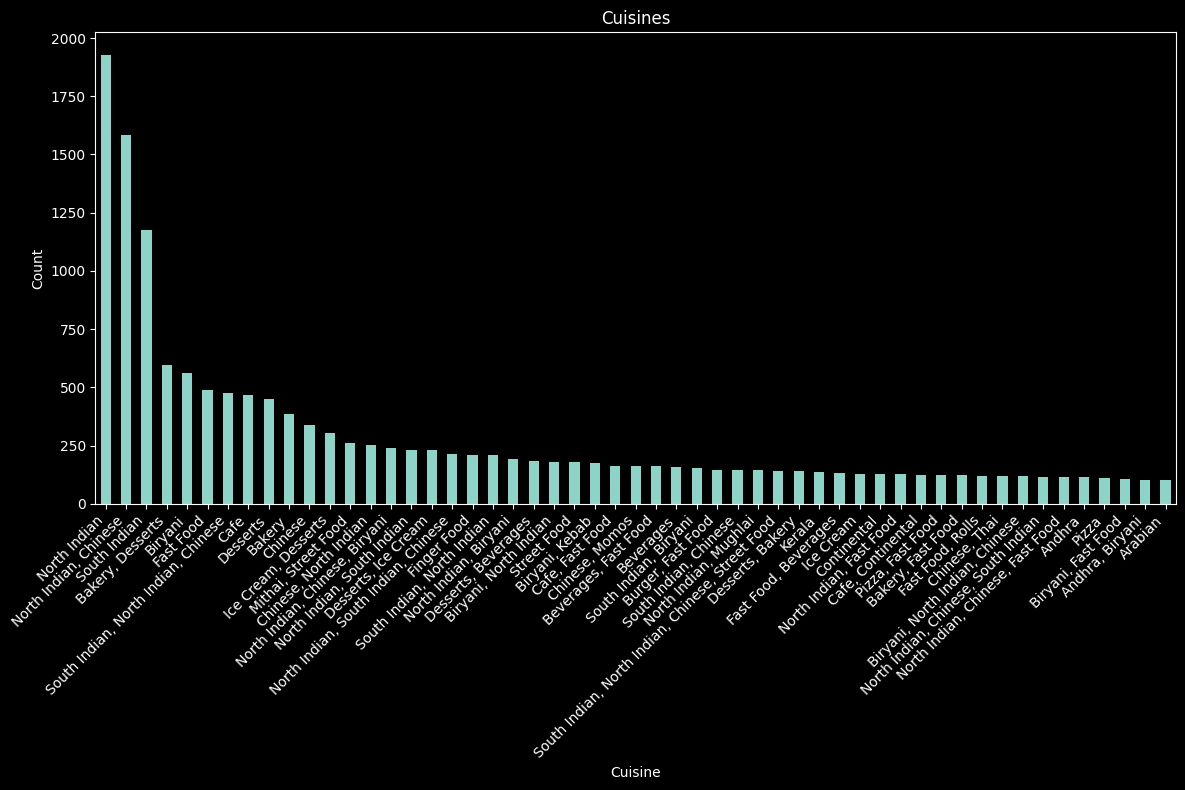

In [68]:
plt.figure(figsize=(12, 8))
df['cuisines'].value_counts(ascending=False).drop('Other', errors='ignore').plot(kind='bar')
plt.title('Cuisines')
plt.xlabel('Cuisine')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [69]:
df.head(10)

,restaurant_name,online_order,book_table,rating,votes,location,rest_type,cuisines,cost_for_two,listed_in(type)
0,Jalsa,Yes,Yes,4.1,775,Banashankari,Casual Dining,Other,800.0,Buffet
1,Spice Elephant,Yes,No,4.1,787,Banashankari,Casual Dining,Other,800.0,Buffet
2,San Churro Cafe,Yes,No,3.8,918,Banashankari,Other,Other,800.0,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7,88,Banashankari,Quick Bites,"South Indian, North Indian",300.0,Buffet
4,Grand Village,No,No,3.8,166,Basavanagudi,Casual Dining,Other,600.0,Buffet
5,Timepass Dinner,Yes,No,3.8,286,Basavanagudi,Casual Dining,North Indian,600.0,Buffet
6,Rosewood International Hotel - Bar & Restaurant,No,No,3.6,8,Other,Casual Dining,Other,800.0,Buffet
7,Onesta,Yes,Yes,4.6,2556,Banashankari,Other,Other,600.0,Cafes
8,Penthouse Cafe,Yes,No,4.0,324,Banashankari,Cafe,Other,700.0,Cafes
9,Smacznego,Yes,No,4.2,504,Banashankari,Cafe,Other,550.0,Cafes


# Визуализация данных (EDA)

Посмотрим в скольких ресторанах можно делать онлайн заказы и в скольких нет

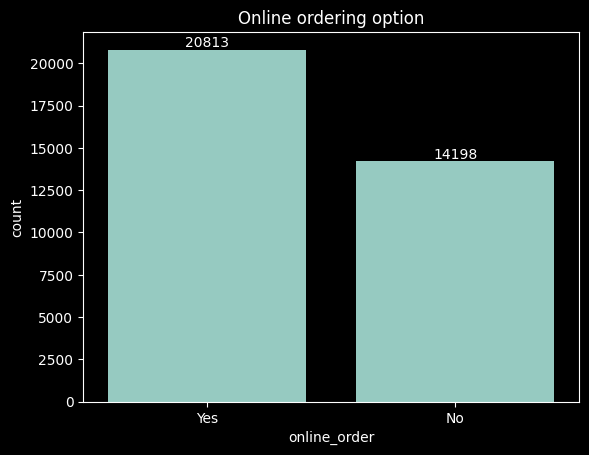

In [105]:
ax=sns.countplot(data=df,x='online_order')
for bars in ax.containers:
    ax.bar_label(bars)
plt.title('Оnline ordering option')
plt.show()

Можем увидеть, что большинство ресторанов принимают онлайн-заказы

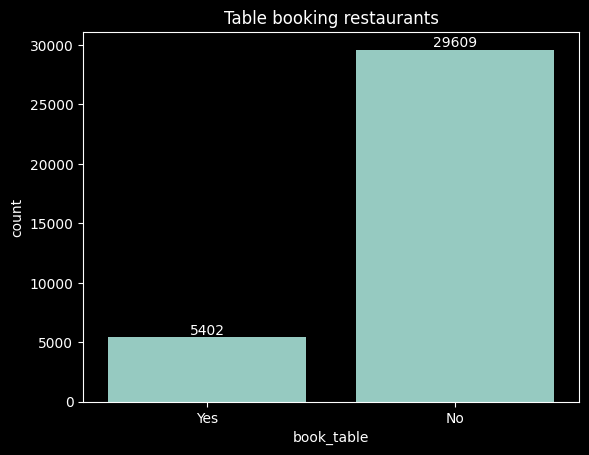

In [102]:
ax=sns.countplot(data=df,x='book_table')
for bars in ax.containers:
    ax.bar_label(bars)
plt.title('Table booking restaurants')
plt.show()

В большинстве ресторанов (29609) нельзя забронировать столик

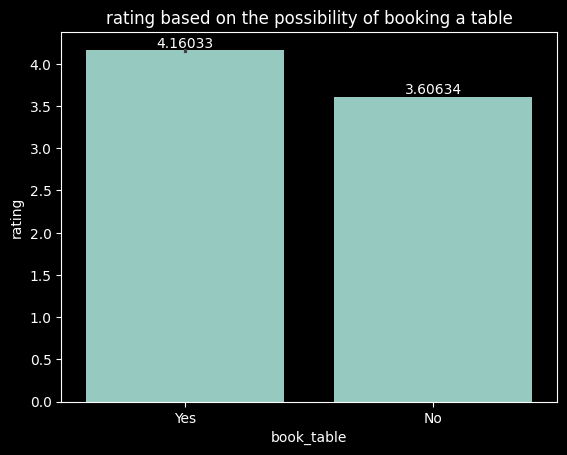

In [108]:
ax=sns.barplot(data=df, x='book_table', y='rating')
for bars in ax.containers:
    ax.bar_label(bars)
plt.title('rating based on the possibility of booking a table')
plt.show()

Можем заметить, что у ресторанов, в которых можно забронировать столик, рейтинг выше, чем у тех, в которых нельзя

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
 [Text(0, 0, 'BTM'),
  Text(1, 0, 'Whitefield'),
  Text(2, 0, 'Indiranagar'),
  Text(3, 0, 'HSR'),
  Text(4, 0, 'Marathahalli'),
  Text(5, 0, 'Koramangala 5th Block'),
  Text(6, 0, 'JP Nagar'),
  Text(7, 0, 'Jayanagar'),
  Text(8, 0, 'Electronic City'),
  Text(9, 0, 'Bellandur')])

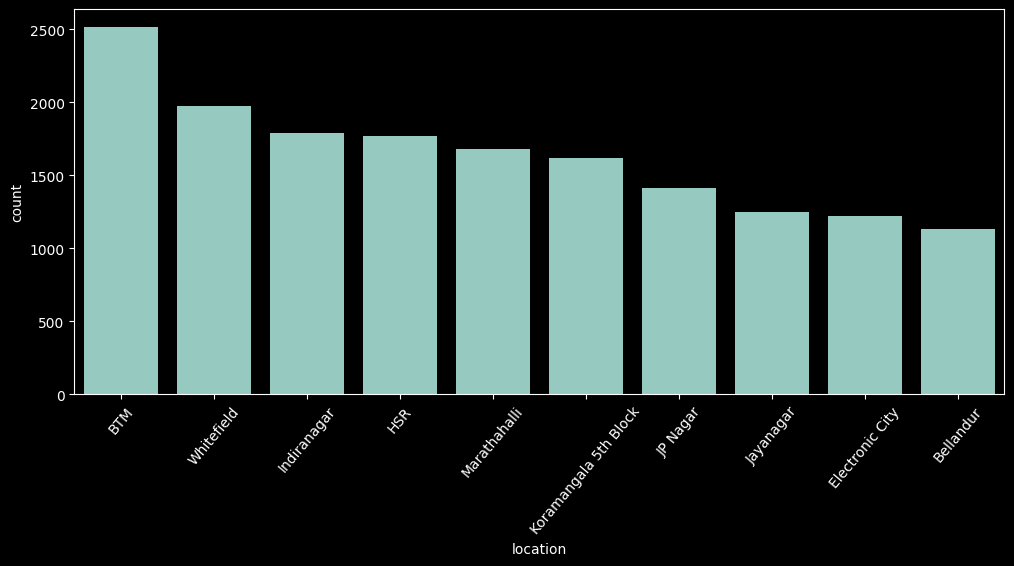

In [116]:
# Топ 10 городов с наибольшим количеством ресторанов
plt.figure(figsize=(12,5))
sns.countplot(x='location',data=df,order=df['location'].value_counts().tail(-1).index[:10])
plt.xticks(rotation=50)

<Axes: xlabel='listed_in(type)', ylabel='count'>

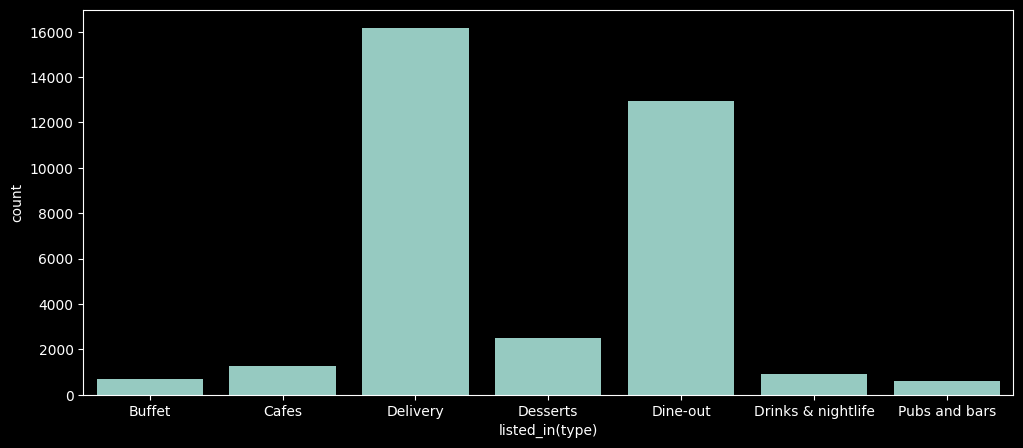

In [120]:
plt.figure(figsize=(12,5))
sns.countplot(data=df,x='listed_in(type)')

Людям нравятся рестораны, которые предлагают доставку и возможность поужинать на месте

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
 [Text(0, 0, 'Koramangala 5th Block'),
  Text(1, 0, 'Richmond Road'),
  Text(2, 0, 'Koramangala 7th Block'),
  Text(3, 0, 'Koramangala 4th Block'),
  Text(4, 0, 'Indiranagar'),
  Text(5, 0, 'MG Road'),
  Text(6, 0, 'Lavelle Road'),
  Text(7, 0, 'Church Street'),
  Text(8, 0, 'Residency Road'),
  Text(9, 0, 'Koramangala 6th Block')])

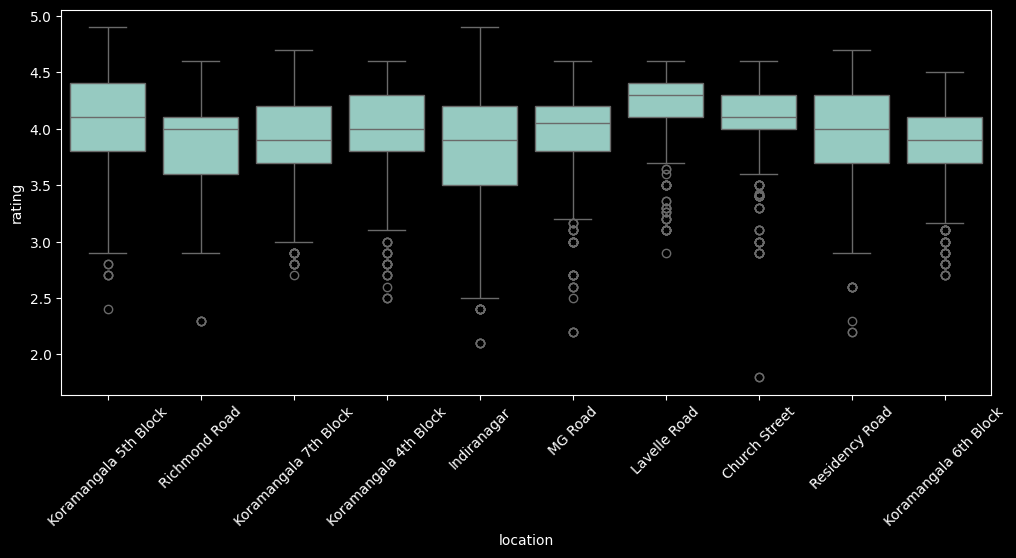

In [124]:
top_locations = df.groupby('location')['rating'].mean().sort_values(ascending=False).head(10)
plt.figure(figsize=(12, 5))
top_location_names = top_locations.index
filtered_df = df[df['location'].isin(top_location_names)]

sns.boxplot(x='location', y='rating', data=filtered_df)
plt.xticks(rotation=45)

Заметим, что у всех заведений рейтинг от 3,5 до 4,5

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
 [Text(0, 0, 'Lavelle Road'),
  Text(1, 0, 'Koramangala 5th Block'),
  Text(2, 0, 'Church Street'),
  Text(3, 0, 'Koramangala 4th Block'),
  Text(4, 0, 'MG Road'),
  Text(5, 0, 'Residency Road'),
  Text(6, 0, 'Koramangala 7th Block'),
  Text(7, 0, 'Richmond Road'),
  Text(8, 0, 'Koramangala 6th Block'),
  Text(9, 0, 'Indiranagar')])

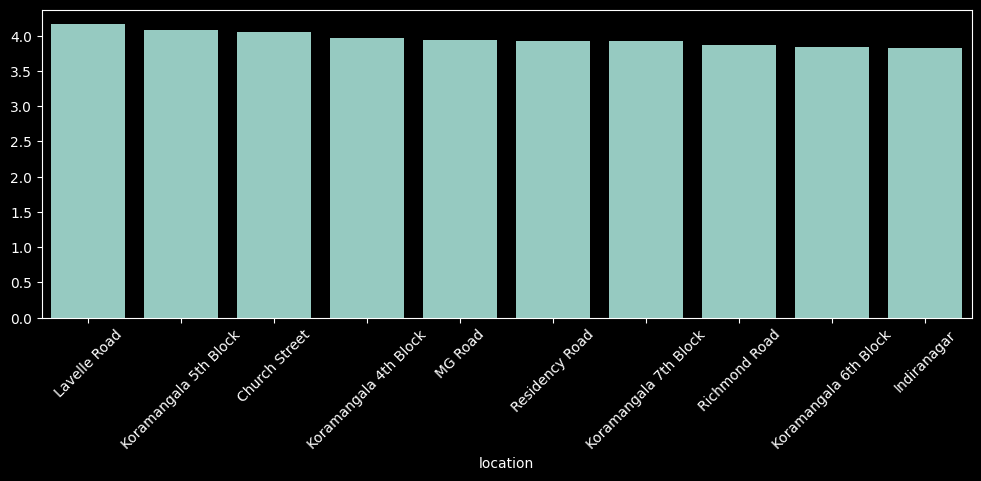

In [131]:
# Города, где рестораны получили наиболее высокие оценки
plt.figure(figsize=(12,4))
top_locations = df.groupby('location')['rating'].mean().sort_values(ascending=False).head(10)
sns.barplot(x=top_locations.index, y=top_locations.values)
plt.xticks(rotation=45)